In [1]:
library(tidyterra)
library(terra)
library(geodata)
library(rnaturalearth)
library(ggplot2)
library(dplyr)
library(sf)
library(rlang)
library(knitr)
library(ggrepel)
library(copula)
library(tidyr)


Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.9.27




Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




...

Linking to GEOS 3.14.1, GDAL 3.13.0, PROJ 9.8.1; sf_use_s2() is TRUE




Attaching package: ‘knitr’




The following object is masked from ‘package:terra’:

    spin





Attaching package: ‘tidyr’




The following object is masked from ‘package:terra’:

    extract




## 1. Motivation

The [Top 14 elevation notebook](05_top14_overlay.html) mapped **home-ground elevation** for all 14 clubs in the 2025–26 French league. This page asks a narrow follow-up question: is **elevation associated with regular-season performance** in that same season?

We use two outcomes from the **2025–26 regular season** (24 of 26 rounds complete at time of writing):

- **League points** (`league_points`) — table points including win/draw/loss and bonus points; the primary outcome.
- **Points for** (`points_for`) — total points scored; a secondary attacking metric.

**Hypothesis (exploratory):** clubs whose home grounds sit higher might differ in league outcomes — whether through altitude acclimatisation, travel fatigue for visitors, or confounded regional factors. French grounds span a **modest elevation band** (~0–650 m in SRTM) compared with URC or Super Rugby, so any signal is unlikely to be large.

**Limitations (read before interpreting):**

- **n = 14** clubs — very low statistical power; wide confidence intervals are expected.
- **Single season** — one snapshot, not a longitudinal study.
- **Home elevation only** — not travel-adjusted or player residence.
- **Confounders** — squad quality, budget, coaching, and region are not controlled.
- **Correlation ≠ causation** — significant or non-significant results here do not establish mechanism.

## 2. Data and merge

In [2]:
top14_clubs <- data.frame(
  club = c(
    "Toulouse", "Toulon", "La Rochelle", "Bordeaux", "Racing 92",
    "Stade Français", "Clermont", "Lyon", "Castres", "Montpellier",
    "Bayonne", "Pau", "Perpignan", "Montauban"
  ),
  stadium = c(
    "Stade Ernest-Wallon", "Stade Mayol", "Stade Marcel-Deflandre (Stade Rochelais)",
    "Matmut Atlantique", "Paris La Défense Arena", "Stade Jean-Bouin",
    "Stade Marcel-Michelin", "Matmut Stadium Gerland", "Stade Pierre-Fabre",
    "GGL Stadium", "Stade Jean-Dauger", "Stade du Hameau",
    "Stade Aimé-Giral", "Stade Sapiac"
  ),
  lon = c(
    1.415, 5.934, -1.17806, -0.598, 2.229,
    2.252, 3.106, 4.832, 2.249, 3.861,
    -1.486, -0.322, 2.894, 1.355
  ),
  lat = c(
    43.621, 43.125, 46.15806, 44.829, 48.895,
    48.844, 45.791, 45.724, 43.601, 43.590,
    43.484, 43.303, 42.711, 44.017
  ),
  region = c(
    "Occitanie", "Provence", "Atlantic coast", "Nouvelle-Aquitaine", "Paris",
    "Paris", "Massif Central", "Rhône-Alpes", "Occitanie", "Occitanie",
    "Basque Country", "Pyrenees", "Occitanie", "Occitanie"
  ),
  stringsAsFactors = FALSE
)

Performance data are stored in a committed CSV (Wikipedia regular-season table, updated 17 May 2026). Official names **Bordeaux Bègles** and **Stade Français Paris** are mapped to `Bordeaux` and `Stade Français` to match the club table above.

In [3]:
top14_results <- read.csv(
  "data/top14_2025_26_regular.csv",
  stringsAsFactors = FALSE
)

stopifnot(nrow(top14_results) == 14L)

In [4]:
fra_elev <- geodata::elevation_30s(country = "FRA", path = tempdir())
fra_boundary <- rnaturalearth::ne_countries(
  country = "France",
  scale = "medium",
  returnclass = "sv"
)

if (!terra::same.crs(fra_elev, fra_boundary)) {
  fra_boundary <- terra::project(fra_boundary, fra_elev)
}

extract_ground_elev <- function(r, lon, lat, radius_deg = 0.05) {
  val <- terra::extract(r, cbind(lon, lat))[[1]]
  if (!is.na(val)) {
    return(as.numeric(val))
  }
  bb <- terra::ext(
    lon - radius_deg,
    lon + radius_deg,
    lat - radius_deg,
    lat + radius_deg
  )
  sub <- terra::crop(r, bb)
  cells <- which(!is.na(terra::values(sub)))
  if (!length(cells)) {
    return(NA_real_)
  }
  xy <- terra::xyFromCell(sub, cells)
  dist2 <- (xy[, 1] - lon)^2 + (xy[, 2] - lat)^2
  vals <- terra::values(sub)[cells]
  as.numeric(vals[which.min(dist2)])
}

fra_elev_crop <- terra::crop(fra_elev, fra_boundary)
names(fra_elev_crop) <- "elevation"

top14_elev <- top14_clubs |>
  mutate(
    ground_elevation_m = mapply(
      extract_ground_elev,
      lon,
      lat,
      MoreArgs = list(r = fra_elev_crop),
      USE.NAMES = FALSE
    )
  )

Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmpie0tpf/elevation/FRA_elv_msk.zip



In [5]:
top14_perf <- top14_elev |>
  left_join(top14_results, by = "club") |>
  mutate(
    league_rank = rank(-league_points, ties.method = "min")
  )

stopifnot(nrow(top14_perf) == 14L)
stopifnot(!any(is.na(top14_perf$ground_elevation_m)))
stopifnot(!any(is.na(top14_perf$league_points)))

top14_perf |>
  arrange(desc(league_points)) |>
  select(
    club, ground_elevation_m, played, league_points, points_for,
    points_against, league_rank
  ) |>
  knitr::kable(
    digits = c(0, 1, 0, 0, 0, 0, 0),
    caption = "Merged Top 14 table: elevation and 2025–26 regular-season performance"
  )



Table: Merged Top 14 table: elevation and 2025–26 regular-season performance

|club           | ground_elevation_m| played| league_points| points_for| points_against| league_rank|
|:--------------|------------------:|------:|-------------:|----------:|--------------:|-----------:|
|Toulouse       |                132|     24|            82|        922|            555|           1|
|Montpellier    |                 43|     24|            74|        770|            544|           2|
|Stade Français |                 46|     24|            73|        809|            616|           3|
|Pau            |                230|     24|            73|        728|            604|           3|
|Bordeaux       |                 13|     24|            68|        769|            658|           5|
|Clermont       |                351|     24|            67|        765|            636|           6|
|Racing 92      |                 50|     24|            65|        756|            690|           7|
|L

## 3. Exploratory views

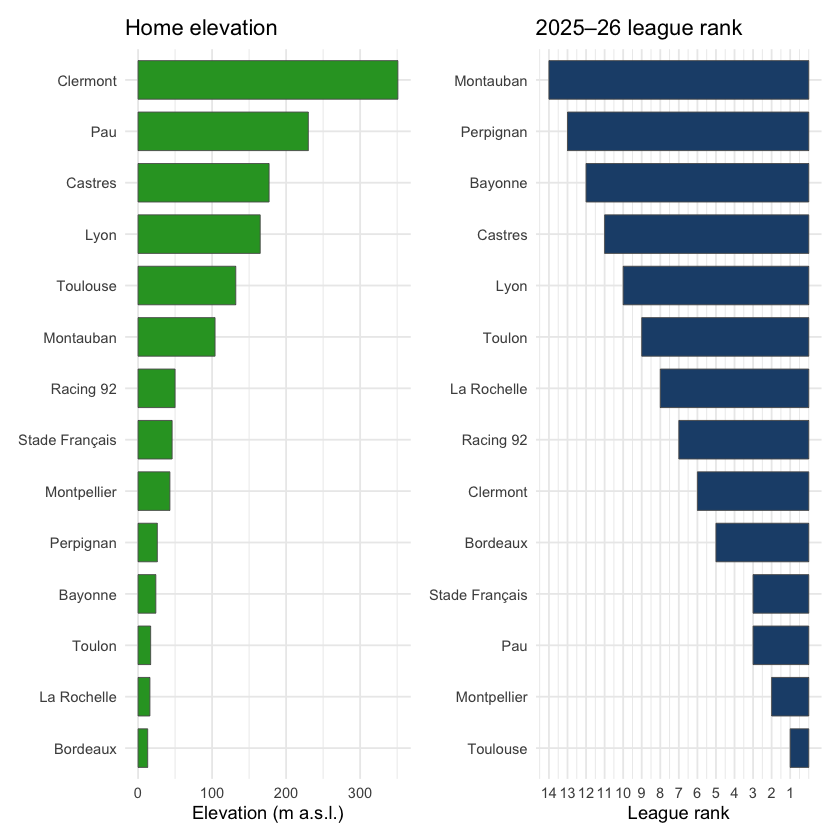

In [6]:
p_elev <- ggplot(top14_perf, aes(x = reorder(club, ground_elevation_m), y = ground_elevation_m)) +
  geom_col(fill = "#2ca02c", width = 0.75, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  labs(x = NULL, y = "Elevation (m a.s.l.)", title = "Home elevation") +
  theme_minimal(base_size = 11)

p_rank <- ggplot(top14_perf, aes(x = reorder(club, -league_points), y = league_rank)) +
  geom_col(fill = "#1f4e79", width = 0.75, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_y_reverse(breaks = 1:14) +
  labs(x = NULL, y = "League rank", title = "2025–26 league rank") +
  theme_minimal(base_size = 11)

if (requireNamespace("patchwork", quietly = TRUE)) {
  patchwork::wrap_plots(p_elev, p_rank, ncol = 2)
} else {
  print(p_elev)
  print(p_rank)
}

`geom_smooth()` using formula = 'y ~ x'


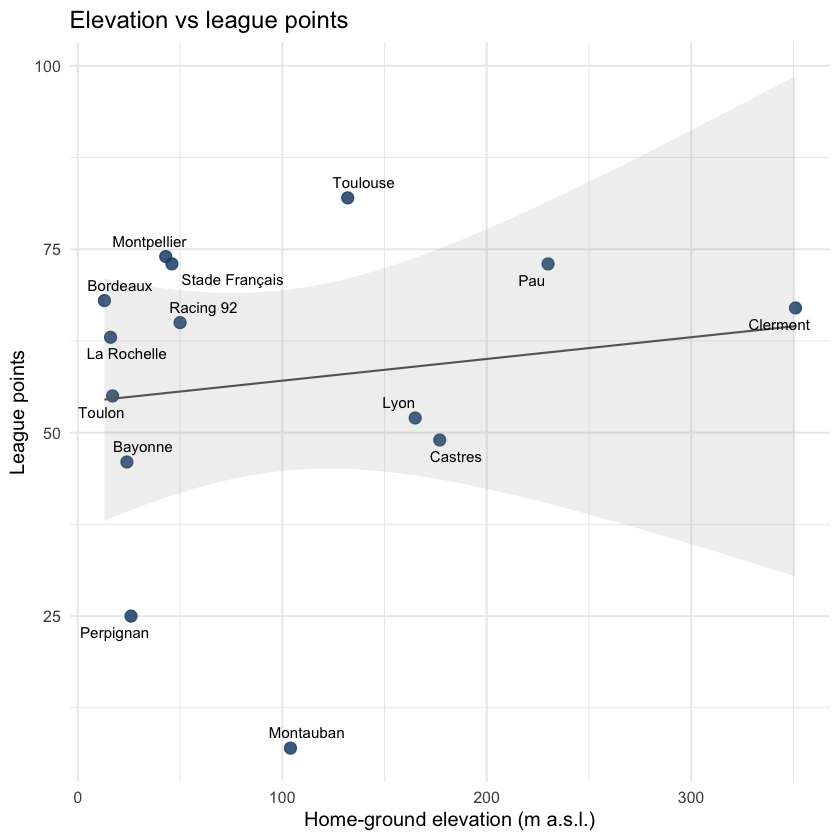

In [7]:
ggplot(top14_perf, aes(x = ground_elevation_m, y = league_points)) +
  geom_point(size = 3, colour = "#1f4e79", alpha = 0.85) +
  geom_smooth(method = "lm", se = TRUE, colour = "grey40", linewidth = 0.6, alpha = 0.15) +
  geom_text_repel(aes(label = club), size = 3.2, max.overlaps = 20, box.padding = 0.35) +
  labs(
    x = "Home-ground elevation (m a.s.l.)",
    y = "League points",
    title = "Elevation vs league points"
  ) +
  theme_minimal(base_size = 12)

`geom_smooth()` using formula = 'y ~ x'


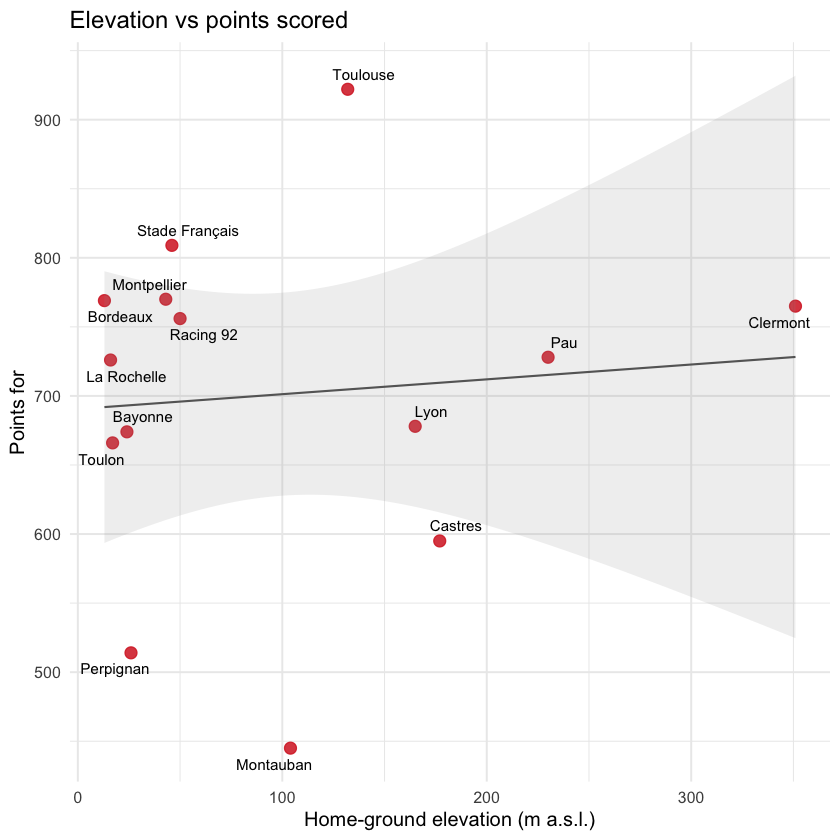

In [8]:
ggplot(top14_perf, aes(x = ground_elevation_m, y = points_for)) +
  geom_point(size = 3, colour = "#d62728", alpha = 0.85) +
  geom_smooth(method = "lm", se = TRUE, colour = "grey40", linewidth = 0.6, alpha = 0.15) +
  geom_text_repel(aes(label = club), size = 3.2, max.overlaps = 20, box.padding = 0.35) +
  labs(
    x = "Home-ground elevation (m a.s.l.)",
    y = "Points for",
    title = "Elevation vs points scored"
  ) +
  theme_minimal(base_size = 12)

## 4. Distributional checks

With **n = 14**, formal normality tests have little power; we inspect histograms and note obvious skew. **Montauban** is a clear outlier on league points and points for (promoted club, relegation zone). Rank-based methods in the next section are partly motivated by this skew.

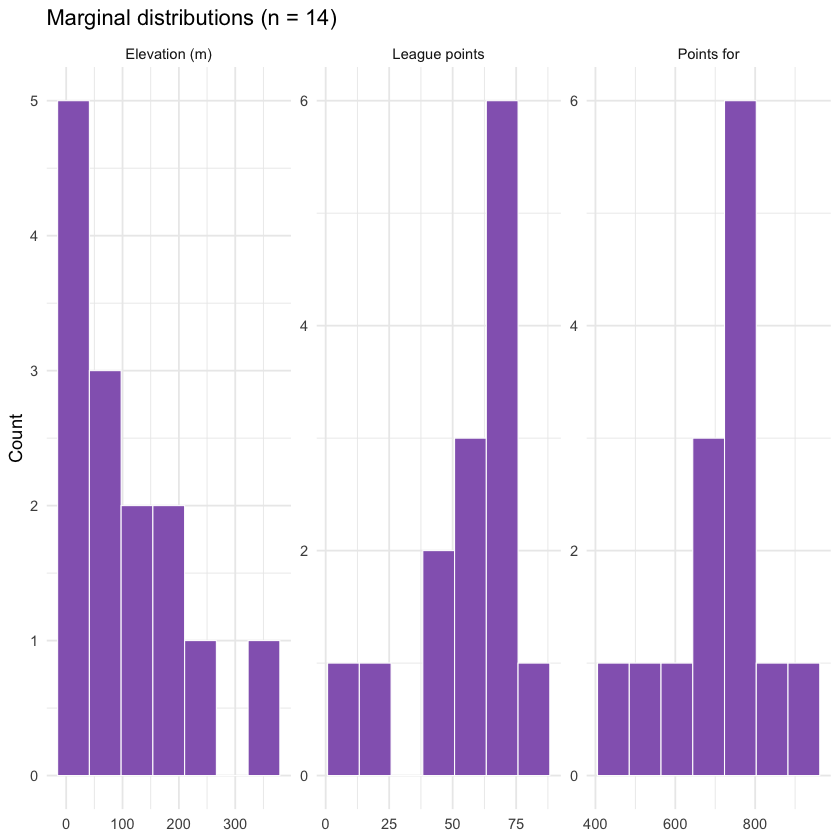

In [9]:
  long_perf <- top14_perf |>
  select(club, ground_elevation_m, league_points, points_for) |>
  pivot_longer(
    -club,
    names_to = "variable",
    values_to = "value"
  ) |>
  mutate(
    variable = factor(
      variable,
      levels = c("ground_elevation_m", "league_points", "points_for"),
      labels = c("Elevation (m)", "League points", "Points for")
    )
  )

ggplot(long_perf, aes(x = value)) +
  geom_histogram(bins = 7, fill = "#9467bd", colour = "white", linewidth = 0.3) +
  facet_wrap(~variable, scales = "free", ncol = 3) +
  labs(x = NULL, y = "Count", title = "Marginal distributions (n = 14)") +
  theme_minimal(base_size = 11)

**Elevation** is right-skewed (most clubs low, Clermont/Pau high). **League points** and **points for** are left-skewed with Montauban separated from the pack. Gaussian copula and normal-scores correlations assume Gaussian **marginals** after transformation; Spearman and Kendall treat ranks directly and are our preferred robust summaries for this sample size.

## 5. Correlation analysis

For each outcome (`league_points`, `points_for`) against `ground_elevation_m` we report:

1. **Pearson** — linear association on the raw scale.
2. **Spearman** — rank correlation (primary robust measure for small n).
3. **Kendall's tau** — alternative rank correlation, stable with ties.
4. **Gaussian (normal-scores) correlation** — ranks mapped to N(0,1) via `qnorm(rank/(n+1))`, then Pearson.
5. **Gaussian copula** — pseudo-observations via `copula::pobs()`, ML fit of `normalCopula(dispstr = "un")`; copula **ρ** and implied Kendall's tau.
6. **Bootstrap** (5,000 resamples) — 95% percentile CI for Spearman ρ and copula ρ.
7. **Permutation test** (9,999 shuffles) — two-sided p-value for Spearman as a check when asymptotics are unreliable.

In [10]:
normal_scores <- function(x) {
  n <- length(x)
  stats::qnorm((rank(x, ties.method = "average") - 0.5) / n)
}

gaussian_scores_cor <- function(x, y) {
  stats::cor(normal_scores(x), normal_scores(y))
}

fit_gaussian_copula <- function(x, y) {
  u <- copula::pobs(cbind(x, y), ties.method = "average")
  fit <- copula::fitCopula(
    copula::normalCopula(dim = 2, dispstr = "un"),
    data = u,
    method = "ml"
  )
  rho <- fit@estimate
  list(
    rho = as.numeric(rho),
    tau = as.numeric(copula::tau(copula::normalCopula(rho, dim = 2, dispstr = "un")))
  )
}

bootstrap_spearman <- function(x, y, R = 5000L, seed = 42L) {
  set.seed(seed)
  n <- length(x)
  rhos <- replicate(R, {
    idx <- sample.int(n, n, replace = TRUE)
    stats::cor(x[idx], y[idx], method = "spearman")
  })
  stats::quantile(rhos, probs = c(0.025, 0.975), na.rm = TRUE)
}

bootstrap_copula_rho <- function(x, y, R = 5000L, seed = 42L) {
  set.seed(seed)
  n <- length(x)
  rhos <- replicate(R, {
    idx <- sample.int(n, n, replace = TRUE)
    fit_gaussian_copula(x[idx], y[idx])$rho
  })
  stats::quantile(rhos, probs = c(0.025, 0.975), na.rm = TRUE)
}

perm_spearman_p <- function(x, y, B = 9999L, seed = 42L) {
  set.seed(seed)
  obs <- stats::cor(x, y, method = "spearman")
  perm <- replicate(B, stats::cor(x, sample(y), method = "spearman"))
  (sum(abs(perm) >= abs(obs)) + 1) / (B + 1)
}

analyse_pair <- function(x, y, outcome_label) {
  pearson <- stats::cor.test(x, y, method = "pearson")
  spearman <- stats::cor.test(x, y, method = "spearman", exact = FALSE)
  kendall <- stats::cor.test(x, y, method = "kendall")
  g_scores_r <- gaussian_scores_cor(x, y)
  cop <- fit_gaussian_copula(x, y)
  boot_s <- bootstrap_spearman(x, y)
  boot_c <- bootstrap_copula_rho(x, y)
  perm_p <- perm_spearman_p(x, y)

  tibble::tibble(
    outcome = outcome_label,
    method = c(
      "Pearson", "Spearman", "Kendall tau",
      "Gaussian normal-scores", "Gaussian copula rho",
      "Spearman (bootstrap CI)", "Copula rho (bootstrap CI)"
    ),
    estimate = c(
      unname(pearson$estimate),
      unname(spearman$estimate),
      unname(kendall$estimate),
      g_scores_r,
      cop$rho,
      unname(spearman$estimate),
      cop$rho
    ),
    ci_low = c(
      pearson$conf.int[1], boot_s[1], NA_real_, NA_real_, NA_real_,
      boot_s[1], boot_c[1]
    ),
    ci_high = c(
      pearson$conf.int[2], boot_s[2], NA_real_, NA_real_, NA_real_,
      boot_s[2], boot_c[2]
    ),
    p_value = c(
      pearson$p.value, spearman$p.value, kendall$p.value,
      NA_real_, NA_real_, perm_p, NA_real_
    ),
    notes = c(
      "Asymptotic", "Asymptotic", "Asymptotic",
      "Normal-scores Pearson", paste0("Copula tau = ", round(cop$tau, 3)),
      "Permutation p for Spearman", "Percentile bootstrap 95% CI"
    )
  )
}

In [11]:
elev <- top14_perf$ground_elevation_m

corr_summary <- dplyr::bind_rows(
  analyse_pair(elev, top14_perf$league_points, "League points"),
  analyse_pair(elev, top14_perf$points_for, "Points for")
)

corr_summary |>
  mutate(
    estimate = round(estimate, 3),
    ci_low = round(ci_low, 3),
    ci_high = round(ci_high, 3),
    p_value = ifelse(is.na(p_value), NA_character_, format.pval(p_value, digits = 3))
  ) |>
  knitr::kable(
    col.names = c("Outcome", "Method", "Estimate", "95% CI low", "95% CI high", "p-value", "Notes"),
    caption = "Correlation of home elevation with performance outcomes (n = 14)"
  )

Warning message in cor.test.default(x, y, method = "kendall"):
“Cannot compute exact p-value with ties”




Table: Correlation of home elevation with performance outcomes (n = 14)

|Outcome       |Method                    | Estimate| 95% CI low| 95% CI high|p-value |Notes                       |
|:-------------|:-------------------------|--------:|----------:|-----------:|:-------|:---------------------------|
|League points |Pearson                   |    0.146|     -0.417|       0.628|0.619   |Asymptotic                  |
|League points |Spearman                  |    0.117|     -0.423|       0.539|0.691   |Asymptotic                  |
|League points |Kendall tau               |    0.022|         NA|          NA|0.913   |Asymptotic                  |
|League points |Gaussian normal-scores    |    0.095|         NA|          NA|NA      |Normal-scores Pearson       |
|League points |Gaussian copula rho       |    0.177|         NA|          NA|NA      |Copula tau = 0.113          |
|League points |Spearman (bootstrap CI)   |    0.117|     -0.423|       0.539|0.679   |Permutation p for S

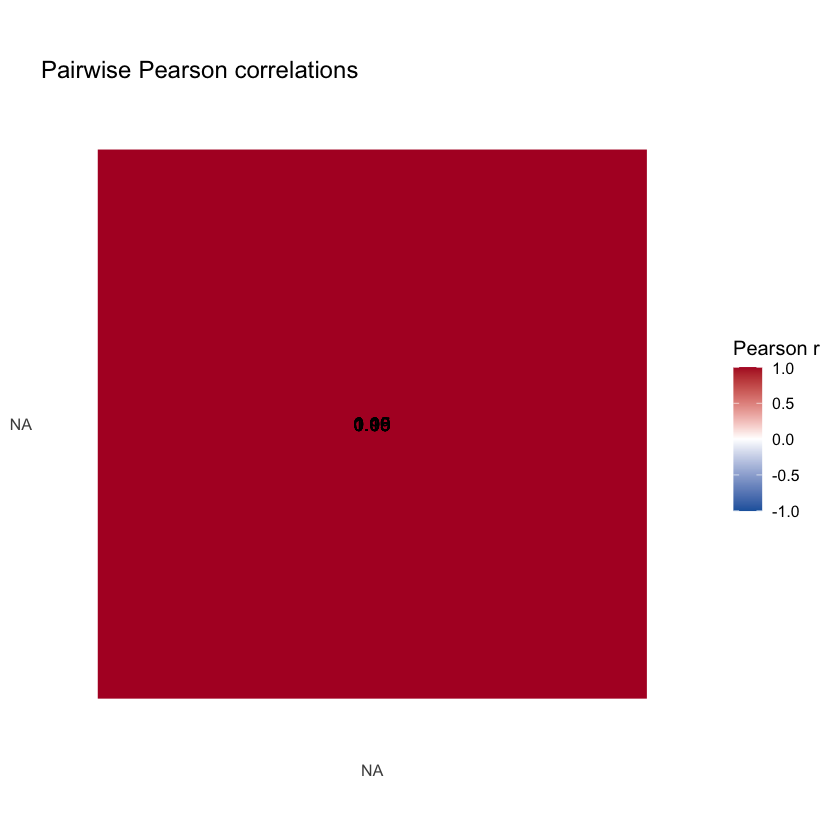

In [12]:
num_mat <- top14_perf |>
  select(ground_elevation_m, league_points, points_for) |>
  as.matrix()

cor_pearson <- stats::cor(num_mat)
cor_labels <- c("Elevation", "League pts", "Points for")

cor_df <- as.data.frame(as.table(cor_pearson))
names(cor_df) <- c("var1", "var2", "r")
cor_df$var1 <- factor(cor_df$var1, levels = cor_labels, labels = cor_labels)
cor_df$var2 <- factor(cor_df$var2, levels = rev(cor_labels), labels = rev(cor_labels))

ggplot(cor_df, aes(var1, var2, fill = r)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f", r)), size = 4) +
  scale_fill_gradient2(
    low = "#2166ac", mid = "white", high = "#b2182b",
    midpoint = 0, limits = c(-1, 1), name = "Pearson r"
  ) +
  coord_fixed() +
  labs(x = NULL, y = NULL, title = "Pairwise Pearson correlations") +
  theme_minimal(base_size = 12) +
  theme(panel.grid = element_blank())

## 6. Interpretation

In [13]:
fmt_r <- function(x) sprintf("%+.2f", x)
fmt_ci <- function(lo, hi) sprintf("[%.2f, %.2f]", lo, hi)

lp_spear <- corr_summary |>
  filter(outcome == "League points", method == "Spearman") |>
  slice(1)
lp_boot <- corr_summary |>
  filter(outcome == "League points", method == "Spearman (bootstrap CI)") |>
  slice(1)
pf_spear <- corr_summary |>
  filter(outcome == "Points for", method == "Spearman") |>
  slice(1)
pf_boot <- corr_summary |>
  filter(outcome == "Points for", method == "Spearman (bootstrap CI)") |>
  slice(1)

cat(sprintf(
  paste0(
    "**League points:** Spearman rho = %s (bootstrap 95%% CI %s; permutation p = %s). ",
    "**Points for:** Spearman rho = %s (bootstrap 95%% CI %s; permutation p = %s).\n\n"
  ),
  fmt_r(lp_spear$estimate), fmt_ci(lp_boot$ci_low, lp_boot$ci_high), lp_boot$p_value,
  fmt_r(pf_spear$estimate), fmt_ci(pf_boot$ci_low, pf_boot$ci_high), pf_boot$p_value
))

**League points:** Spearman rho = +0.12 (bootstrap 95% CI [-0.42, 0.54]; permutation p = 0.679). **Points for:** Spearman rho = +0.04 (bootstrap 95% CI [-0.45, 0.53]; permutation p = 0.8945).



With **n = 14** and a **narrow elevation range**, confidence intervals for all methods are wide and typically **include zero**. That pattern means we have **no reliable statistical evidence** that home-ground elevation predicts 2025–26 Top 14 league points or points scored — not that elevation is definitively unrelated, but that this sample cannot distinguish weak associations from noise.

**Clermont** and **Pau** sit at the high-elevation end; **Toulouse** led the table from a mid-altitude ground. **Montauban** dominates the lower tail of performance metrics regardless of elevation. Any visual trend in the scatter plots should be read as **hypothesis-generating**, not confirmatory.

This page’s value is the **transparent workflow**: merge geospatial elevation with a single-season table, inspect distributions, and compare Pearson, rank, normal-scores, and copula dependence measures with bootstrap and permutation checks — while stating clearly that **correlation does not imply causation** and that a definitive test would need more seasons, more leagues, and covariate control.